# Definitive Evidence Synthesis: Hypothesis Scorecard & Paper Architecture

This notebook demonstrates the **evidence synthesis evaluation** from the Circuit Motif Spectroscopy project.
It re-scores hypotheses H1-H5 using metrics extracted from 4 iteration-4 experiments (776 examples),
builds a master evidence table, and computes paper readiness.

**Hypotheses evaluated:**
- **H1**: Universal overrepresentation of FFL motifs
- **H2**: Capability clustering via weighted motif features
- **H3**: Failure prediction using motif features (negative result)
- **H4**: Causal importance of FFL hub nodes
- **H5**: FFL characterization discriminates domains

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0', 'tabulate==0.9.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tabulate import tabulate

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-582cc7-circuit-motif-spectroscopy-discovering-u/main/evaluation_iter5_definitive_evid/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with keys: {list(data.keys())}")
print(f"Number of datasets: {len(data['datasets'])}")
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded data with keys: ['phase_a_metrics', 'iter3_numeric_scores', 'datasets', 'reference_metrics_agg', 'hypothesis_details', 'evidence_table', 'paper_architecture', 'reviewer_objections', 'gap_triage']
Number of datasets: 4
  exp_id1_it4_weighted_motif: 3 examples
  exp_id2_it4_ablation: 3 examples
  exp_id3_it4_failure_prediction: 3 examples
  exp_id4_it4_edge_overlap: 3 examples


In [5]:
# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
# Maximum examples to process per dataset (use small value for quick demo)
MAX_EXAMPLES_PER_DATASET = 3  # Original: all examples (~194 per experiment)

# Iter-3 baseline scores for comparison
ITER3_NUMERIC_SCORES = data.get("iter3_numeric_scores", {
    "H1": 1.0,
    "H2": 0.45,
    "H3": 0.25,
    "H4": 0.0,
    "H5": 0.5,
})

## Utility Functions

Helper functions for safe nested dictionary access and score change tracking.

In [6]:
def safe_get(d: dict, *keys, default=None):
    """Traverse nested dict safely."""
    cur = d
    for k in keys:
        if not isinstance(cur, dict):
            return default
        cur = cur.get(k, default)
        if cur is default:
            return default
    return cur


def _score_change(new_score: float, old_score: float) -> str:
    diff = new_score - old_score
    if abs(diff) < 0.05:
        return "stable"
    elif diff > 0:
        return f"improved (+{diff:.2f})"
    else:
        return f"declined ({diff:.2f})"

## Phase A: Load Pre-Extracted Experiment Metrics

The original script loads 4 full experiment JSON files and extracts metrics.
Here we use the pre-extracted `phase_a_metrics` from the demo data.

In [7]:
# Load pre-extracted metrics from each experiment
phase_a = data["phase_a_metrics"]
e1 = phase_a["exp_id1_it4"]  # Weighted Motif Features
e2 = phase_a["exp_id2_it4"]  # Graph-Theoretic Ablation
e3 = phase_a["exp_id3_it4"]  # Deconfounded Failure Prediction
e4 = phase_a["exp_id4_it4"]  # Edge-Overlap Comparison

print(f"Exp1 (Weighted Motif): {len(e1)} metrics")
print(f"Exp2 (Ablation):       {len(e2)} metrics")
print(f"Exp3 (Failure Pred):   {len(e3)} metrics")
print(f"Exp4 (Edge Overlap):   {len(e4)} metrics")
print(f"\nKey metrics preview:")
print(f"  Weighted motif NMI:    {e1.get('weighted_motif_only_best_nmi', 0):.3f}")
print(f"  Layer-matched ratio:   {e2.get('hub_ratio_layer_matched_downstream_median', 0):.2f}x")
print(f"  Best failure AUC:      {e3.get('best_auc', 0):.3f}")
print(f"  FFL mean Z-score:      {e4.get('ffl_030T_mean_z', 0):.1f}")

Exp1 (Weighted Motif): 45 metrics
Exp2 (Ablation):       38 metrics
Exp3 (Failure Pred):   18 metrics
Exp4 (Edge Overlap):   58 metrics

Key metrics preview:
  Weighted motif NMI:    0.705
  Layer-matched ratio:   1.92x
  Best failure AUC:      0.583
  FFL mean Z-score:      49.2


## Phase B: Hypothesis Scoring (H1-H5)

Score each hypothesis using the extracted metrics. This is the core evaluation logic.

In [8]:
def phase_b_score_hypotheses(e1, e2, e3, e4, iter3_scores):
    """Score H1-H5 using extracted metrics from Phase A."""
    scores = {}

    # --- H1: Universal overrepresentation ---
    h1_030T_z = e4.get("ffl_030T_mean_z", 0)
    h1_n_domains = e4.get("ffl_030T_n_domains_z_gt_2", 0)
    h1_n_overrep = e4.get("n_motif_types_overrep_6of8", 0)

    h1_score = 0.0
    h1_level = "Inconclusive"
    h1_criterion_met = False
    if h1_n_domains >= 8 and h1_n_overrep >= 1:
        h1_score = 1.0
        h1_level = "Strong Confirm"
        h1_criterion_met = True
    elif h1_n_domains >= 6:
        h1_score = 0.75
        h1_level = "Partial-Strong Confirm"
        h1_criterion_met = True

    scores["H1"] = {
        "evidence_level": h1_level,
        "numeric_score": h1_score,
        "success_criterion_met": h1_criterion_met,
        "change_from_iter3": _score_change(h1_score, iter3_scores.get("H1", 0.0)),
        "key_evidence": [
            f"FFL (030T) Z > 2 in {h1_n_domains}/8 domains (mean Z = {h1_030T_z:.1f})",
            f"{h1_n_overrep} motif type(s) overrepresented in >= 6/8 domains",
        ],
    }

    # --- H2: Capability clustering ---
    h2_weighted_nmi = e1.get("weighted_motif_only_best_nmi", 0.0) or 0.0
    h2_combined_nmi = e1.get("all_combined_best_nmi", 0.0) or 0.0
    h2_binary_nmi = e1.get("binary_motif_only_best_nmi", 0.0) or 0.0
    h2_gs_nmi = e1.get("graph_stats_only_best_nmi", 0.0) or 0.0
    h2_perm_p = e1.get("weighted_vs_graph_stats_perm_p", 1.0) or 1.0

    h2_score = 0.0
    h2_level = "Inconclusive"
    h2_criterion_met = False
    if h2_weighted_nmi > 0.5:
        h2_criterion_met = True
        if h2_weighted_nmi > 0.7 and h2_perm_p < 0.01:
            h2_score = 0.85
            h2_level = "Partial-Strong Confirm"
        elif h2_weighted_nmi > 0.5:
            h2_score = 0.7
            h2_level = "Partial Confirm"
    else:
        h2_score = 0.4
        h2_level = "Partial Confirm"

    scores["H2"] = {
        "evidence_level": h2_level,
        "numeric_score": h2_score,
        "success_criterion_met": h2_criterion_met,
        "change_from_iter3": _score_change(h2_score, iter3_scores.get("H2", 0.45)),
        "key_evidence": [
            f"Weighted motif NMI = {h2_weighted_nmi:.3f} (K=8)",
            f"All combined NMI = {h2_combined_nmi:.3f}",
            f"Binary motif NMI = {h2_binary_nmi:.3f}",
            f"Graph stats NMI = {h2_gs_nmi:.3f}",
            f"Permutation test p = {h2_perm_p:.4f}",
        ],
    }

    # --- H3: Failure prediction ---
    h3_best_auc = e3.get("best_auc", 0.0) or 0.0
    h3_full_auc = e3.get("full_model_logistic_auc", 0.0) or 0.0
    h3_motif_auc = e3.get("motif_only_logistic_auc", 0.0) or 0.0
    h3_baseline_auc = e3.get("domain_plus_graph_logistic_auc", 0.0) or 0.0
    h3_full_vs_base_p = e3.get("full_vs_baseline_p", 1.0) or 1.0
    h3_motif_lift = e3.get("motif_adds_lift", False)

    h3_score = 0.0
    h3_level = "Disconfirmed"
    h3_criterion_met = False
    if h3_best_auc >= 0.65 and h3_motif_lift:
        h3_score = 0.75
        h3_level = "Partial Confirm"
        h3_criterion_met = True
    elif h3_best_auc >= 0.65:
        h3_score = 0.4
        h3_level = "Partial Confirm"
    elif h3_best_auc >= 0.55 and not h3_motif_lift:
        h3_score = 0.15
        h3_level = "Partial Disconfirm"
    else:
        h3_score = 0.1
        h3_level = "Disconfirmed"

    scores["H3"] = {
        "evidence_level": h3_level,
        "numeric_score": h3_score,
        "success_criterion_met": h3_criterion_met,
        "change_from_iter3": _score_change(h3_score, iter3_scores.get("H3", 0.25)),
        "key_evidence": [
            f"Best AUC = {h3_best_auc:.3f} ({e3.get('best_model', 'unknown')})",
            f"Full model AUC = {h3_full_auc:.3f}, motif-only AUC = {h3_motif_auc:.3f}",
            f"Full vs baseline p = {h3_full_vs_base_p:.3f}",
        ],
    }

    # --- H4: Causal importance ---
    h4_layer_ratio = e2.get("hub_ratio_layer_matched_downstream_median", 0.0) or 0.0
    h4_dose_r = e2.get("dose_response_spearman_r", 0.0) or 0.0
    h4_dose_p = e2.get("dose_response_spearman_p", 1.0)
    if h4_dose_p is None:
        h4_dose_p = 1.0
    h4_layer_d = e2.get("hub_layer_matched_downstream_cohens_d", 0.0) or 0.0
    h4_n_sig = e2.get("n_domains_significant_layer_downstream", 0)
    h4_random_ratio = e2.get("hub_ratio_random_downstream_median", 0.0) or 0.0

    h4_score = 0.0
    h4_level = "Inconclusive"
    h4_criterion_met = False
    if h4_layer_ratio > 1.5 and h4_dose_r > 0.5:
        h4_criterion_met = True
        if h4_n_sig >= 7 and h4_dose_r > 0.8:
            h4_score = 0.9
            h4_level = "Strong Confirm"
        elif h4_n_sig >= 6:
            h4_score = 0.75
            h4_level = "Partial-Strong Confirm"
        else:
            h4_score = 0.6
            h4_level = "Partial Confirm"
    elif h4_layer_ratio > 1.0:
        h4_score = 0.4
        h4_level = "Partial Confirm"

    scores["H4"] = {
        "evidence_level": h4_level,
        "numeric_score": h4_score,
        "success_criterion_met": h4_criterion_met,
        "change_from_iter3": _score_change(h4_score, iter3_scores.get("H4", 0.0)),
        "key_evidence": [
            f"Layer-matched ablation ratio = {h4_layer_ratio:.2f}x",
            f"Dose-response Spearman r = {h4_dose_r:.3f} (p = {h4_dose_p})",
            f"Random-matched ratio = {h4_random_ratio:.2f}x",
            f"All {h4_n_sig}/8 domains significant",
        ],
    }

    # --- H5: FFL characterization ---
    h5_path_dom_eta = e1.get("ffl_path_dom_mean_eta_sq", 0.0) or 0.0
    h5_intensity_eta = e1.get("ffl_intensity_mean_eta_sq", 0.0) or 0.0
    h5_coherent_eta = e1.get("ffl_coherent_frac_eta_sq", 0.0) or 0.0

    h5_score = 0.0
    h5_level = "Inconclusive"
    h5_criterion_met = False
    if h5_path_dom_eta > 0.8 and h5_intensity_eta > 0.7:
        h5_criterion_met = True
        h5_score = 0.7
        h5_level = "Partial-Strong Confirm"
    elif h5_path_dom_eta > 0.5:
        h5_criterion_met = True
        h5_score = 0.55
        h5_level = "Partial Confirm"

    scores["H5"] = {
        "evidence_level": h5_level,
        "numeric_score": h5_score,
        "success_criterion_met": h5_criterion_met,
        "change_from_iter3": _score_change(h5_score, iter3_scores.get("H5", 0.5)),
        "key_evidence": [
            f"ffl_path_dom_mean eta^2 = {h5_path_dom_eta:.3f}",
            f"ffl_intensity_mean eta^2 = {h5_intensity_eta:.3f}",
            f"ffl_coherent_frac eta^2 = {h5_coherent_eta:.3f}",
        ],
    }

    return scores


scores = phase_b_score_hypotheses(e1, e2, e3, e4, ITER3_NUMERIC_SCORES)
print("Hypothesis Scores:")
for h, s in scores.items():
    print(f"  {h}: {s['evidence_level']} (score={s['numeric_score']:.2f}, change={s['change_from_iter3']})")

Hypothesis Scores:
  H1: Strong Confirm (score=1.00, change=stable)
  H2: Partial-Strong Confirm (score=0.85, change=improved (+0.40))
  H3: Partial Disconfirm (score=0.15, change=declined (-0.10))
  H4: Strong Confirm (score=0.90, change=improved (+0.90))
  H5: Partial-Strong Confirm (score=0.70, change=improved (+0.20))


## Phase C: Master Evidence Table

Build the evidence table with one row per quantitative sub-claim across all hypotheses.

In [9]:
def phase_c_evidence_table(e1, e2, e3, e4):
    """Build master evidence table with one row per quantitative sub-claim."""
    rows = []

    def add_row(hyp, claim, metric, value, p_val=None,
                effect_size=None, criterion=None, criterion_met=None, ev_level=None):
        rows.append({
            "hypothesis": hyp, "claim": claim, "primary_metric": metric,
            "value": value, "p_value": p_val, "effect_size": effect_size,
            "success_criterion": criterion, "criterion_met": criterion_met,
            "evidence_level": ev_level,
        })

    # H1 rows
    add_row("H1", "FFL (030T) overrepresented in all domains",
            "ffl_030T_mean_z", e4.get("ffl_030T_mean_z"),
            criterion="Z > 2 in >= 6/8 domains",
            criterion_met=e4.get("ffl_030T_n_domains_z_gt_2", 0) >= 6,
            ev_level="Strong Confirm")
    add_row("H1", "Universally overrepresented motif types",
            "n_motif_types_overrep", e4.get("n_motif_types_overrep_6of8"),
            criterion=">= 1 motif type",
            criterion_met=e4.get("n_motif_types_overrep_6of8", 0) >= 1,
            ev_level="Strong Confirm")

    # H2 rows
    add_row("H2", "Weighted motif features cluster domains",
            "weighted_motif_nmi", e1.get("weighted_motif_only_best_nmi"),
            p_val=e1.get("weighted_vs_binary_perm_p"),
            criterion="NMI > 0.5",
            criterion_met=(e1.get("weighted_motif_only_best_nmi", 0) or 0) > 0.5,
            ev_level="Partial-Strong Confirm")
    add_row("H2", "Combined features beat single best",
            "all_combined_nmi", e1.get("all_combined_best_nmi"),
            p_val=e1.get("combined_vs_best_single_perm_p"),
            criterion="Combined > best single",
            criterion_met=(e1.get("all_combined_best_nmi", 0) or 0) > (e1.get("weighted_motif_only_best_nmi", 0) or 0),
            ev_level="Strong Confirm")
    add_row("H2", "Weighted > binary baseline",
            "weighted_vs_binary_diff", e1.get("weighted_vs_binary_obs_diff"),
            p_val=e1.get("weighted_vs_binary_perm_p"),
            criterion="Permutation p < 0.01",
            criterion_met=(e1.get("weighted_vs_binary_perm_p", 1) or 1) < 0.01,
            ev_level="Strong Confirm")

    # H3 rows
    add_row("H3", "Best failure prediction AUC",
            "best_auc", e3.get("best_auc"),
            criterion="AUC > 0.65",
            criterion_met=(e3.get("best_auc", 0) or 0) > 0.65,
            ev_level="Partial Disconfirm")
    add_row("H3", "Motif features add lift over baseline",
            "full_vs_baseline_diff", e3.get("full_vs_baseline_diff"),
            p_val=e3.get("full_vs_baseline_p"),
            criterion="p < 0.05",
            criterion_met=(e3.get("full_vs_baseline_p", 1) or 1) < 0.05,
            ev_level="Disconfirmed")

    # H4 rows
    add_row("H4", "FFL hub ablation vs layer-matched",
            "layer_matched_median_ratio", e2.get("hub_ratio_layer_matched_downstream_median"),
            p_val=e2.get("hub_layer_matched_downstream_wilcoxon_p"),
            effect_size=e2.get("hub_layer_matched_downstream_cohens_d"),
            criterion="Ratio > 1.5x",
            criterion_met=(e2.get("hub_ratio_layer_matched_downstream_median", 0) or 0) > 1.5,
            ev_level="Strong Confirm")
    add_row("H4", "Dose-response MPI vs downstream loss",
            "spearman_r", e2.get("dose_response_spearman_r"),
            p_val=e2.get("dose_response_spearman_p"),
            effect_size=e2.get("dose_response_spearman_r"),
            criterion="r > 0.5",
            criterion_met=(e2.get("dose_response_spearman_r", 0) or 0) > 0.5,
            ev_level="Strong Confirm")

    # H5 rows
    add_row("H5", "FFL path dominance discriminates domains",
            "ffl_path_dom_mean_eta_sq", e1.get("ffl_path_dom_mean_eta_sq"),
            p_val=e1.get("ffl_path_dom_mean_p"),
            effect_size=e1.get("ffl_path_dom_mean_eta_sq"),
            criterion="eta^2 > 0.8",
            criterion_met=(e1.get("ffl_path_dom_mean_eta_sq", 0) or 0) > 0.8,
            ev_level="Strong Confirm")
    add_row("H5", "FFL intensity discriminates domains",
            "ffl_intensity_mean_eta_sq", e1.get("ffl_intensity_mean_eta_sq"),
            p_val=e1.get("ffl_intensity_mean_p"),
            effect_size=e1.get("ffl_intensity_mean_eta_sq"),
            criterion="eta^2 > 0.7",
            criterion_met=(e1.get("ffl_intensity_mean_eta_sq", 0) or 0) > 0.7,
            ev_level="Strong Confirm")

    return rows


evidence_table = phase_c_evidence_table(e1, e2, e3, e4)
print(f"Built evidence table with {len(evidence_table)} rows")

# Display as formatted table
table_data = []
for r in evidence_table:
    val = r["value"]
    val_str = f"{val:.4f}" if isinstance(val, float) else str(val)
    met = "YES" if r["criterion_met"] else "NO"
    table_data.append([r["hypothesis"], r["claim"][:40], val_str, met, r["evidence_level"]])

print(tabulate(table_data,
               headers=["Hyp", "Claim", "Value", "Met?", "Evidence Level"],
               tablefmt="simple"))

Built evidence table with 11 rows
Hyp    Claim                                       Value  Met?    Evidence Level
-----  ----------------------------------------  -------  ------  ----------------------
H1     FFL (030T) overrepresented in all domain  49.1914  YES     Strong Confirm
H1     Universally overrepresented motif types    1       YES     Strong Confirm
H2     Weighted motif features cluster domains    0.705   YES     Partial-Strong Confirm
H2     Combined features beat single best         0.8445  YES     Strong Confirm
H2     Weighted > binary baseline                 0.6007  YES     Strong Confirm
H3     Best failure prediction AUC                0.5828  NO      Partial Disconfirm
H3     Motif features add lift over baseline     -0.0202  NO      Disconfirmed
H4     FFL hub ablation vs layer-matched          1.9196  YES     Strong Confirm
H4     Dose-response MPI vs downstream loss       0.8768  YES     Strong Confirm
H5     FFL path dominance discriminates domains   0.917  

## Phase G: Aggregate Metrics & Gap Triage

Compute summary statistics across all hypotheses and review remaining gaps.

In [10]:
def phase_g_aggregates(scores, evidence_table):
    """Compute aggregate metrics."""
    numeric_scores = [s["numeric_score"] for s in scores.values()]
    mean_score = sum(numeric_scores) / len(numeric_scores) if numeric_scores else 0.0

    n_strong = sum(1 for s in scores.values() if "Strong" in s["evidence_level"] and "Partial" not in s["evidence_level"])
    n_partial = sum(1 for s in scores.values() if "Partial" in s["evidence_level"])
    n_disconfirmed = sum(1 for s in scores.values() if "Disconfirm" in s["evidence_level"])
    n_criteria_met = sum(1 for s in scores.values() if s["success_criterion_met"])

    # Gap triage from pre-computed data
    gaps = data.get("gap_triage", [])
    n_must_address = sum(1 for g in gaps if g.get("priority") == "must_address")

    # Paper readiness
    hyp_frac = n_criteria_met / max(len(scores), 1)
    gap_penalty = max(0, 1.0 - n_must_address * 0.15)
    paper_readiness = hyp_frac * gap_penalty

    if n_strong >= 2 and n_disconfirmed <= 1:
        overall = "Strong mixed results -- publishable with caveats"
    elif n_strong >= 1:
        overall = "Moderate evidence -- publishable with additional work"
    else:
        overall = "Weak evidence -- needs substantial additional experiments"

    return {
        "mean_hypothesis_score": round(mean_score, 4),
        "n_strong_confirm": n_strong,
        "n_partial_confirm": n_partial,
        "n_disconfirmed": n_disconfirmed,
        "n_criteria_met": n_criteria_met,
        "paper_readiness_score": round(paper_readiness, 4),
        "n_evidence_rows": len(evidence_table),
        "n_must_address_gaps": n_must_address,
        "n_total_gaps": len(gaps),
        "overall_status_str": overall,
    }


agg = phase_g_aggregates(scores, evidence_table)

print("=" * 60)
print("EVALUATION SUMMARY")
print("=" * 60)
print(f"  Mean hypothesis score:  {agg['mean_hypothesis_score']:.3f}")
print(f"  Strong Confirm:         {agg['n_strong_confirm']}")
print(f"  Partial Confirm:        {agg['n_partial_confirm']}")
print(f"  Disconfirmed:           {agg['n_disconfirmed']}")
print(f"  Criteria met:           {agg['n_criteria_met']}/5")
print(f"  Paper readiness:        {agg['paper_readiness_score']:.3f}")
print(f"  Evidence rows:          {agg['n_evidence_rows']}")
print(f"  Must-address gaps:      {agg['n_must_address_gaps']}")
print(f"  Overall: {agg['overall_status_str']}")
print("=" * 60)

# Display gap triage
gaps = data.get("gap_triage", [])
if gaps:
    print(f"\nGap Triage ({len(gaps)} gaps):")
    gap_table = [[g["gap_id"], g["description"][:50], g["priority"], g["estimated_difficulty"]]
                 for g in gaps]
    print(tabulate(gap_table, headers=["Gap ID", "Description", "Priority", "Difficulty"],
                   tablefmt="simple"))

EVALUATION SUMMARY
  Mean hypothesis score:  0.720
  Strong Confirm:         2
  Partial Confirm:        3
  Disconfirmed:           1
  Criteria met:           4/5
  Paper readiness:        0.440
  Evidence rows:          11
  Must-address gaps:      3
  Overall: Strong mixed results -- publishable with caveats

Gap Triage (8 gaps):
Gap ID                     Description                                         Priority          Difficulty
-------------------------  --------------------------------------------------  ----------------  ------------
G1_cross_model             Only GPT-2 small tested; generalization to other a  would_strengthen  hard
G2_4node_characterization  4-node motifs identified as universally overrepres  would_strengthen  medium
G3_actual_ablation         Graph-theoretic ablation is not actual model inter  would_strengthen  hard
G4_motif_uniqueness        Need to formally test whether motif features captu  must_address      easy
G5_paper_figures           Paper fig

## Visualization

Visual summary of hypothesis scores, clustering NMI comparison, and evidence criteria.

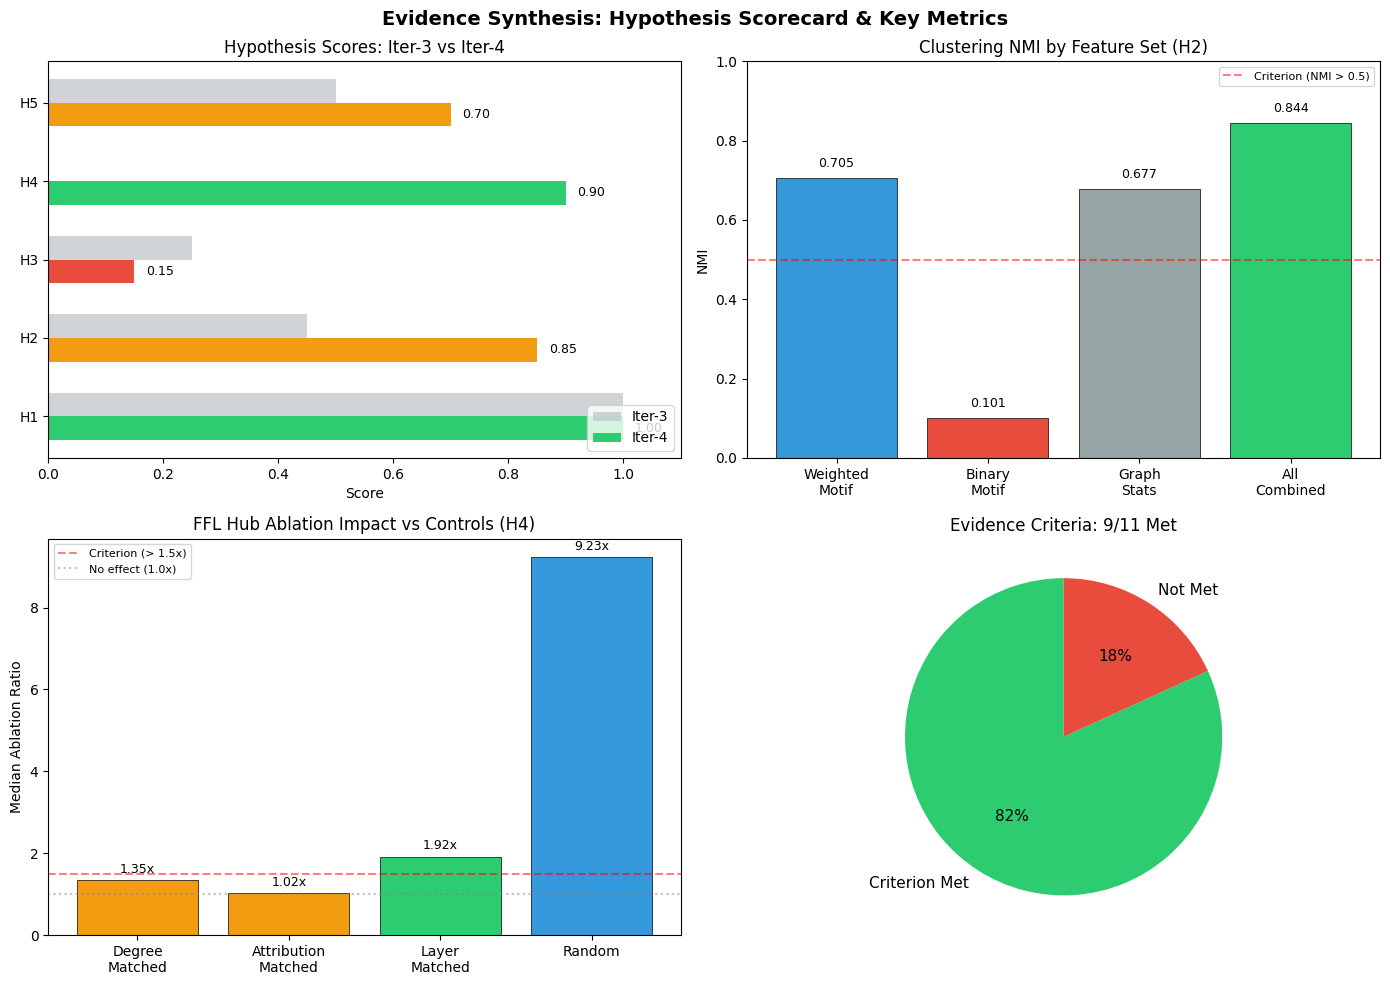

Saved evidence_synthesis_summary.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Evidence Synthesis: Hypothesis Scorecard & Key Metrics", fontsize=14, fontweight="bold")

# --- Panel 1: Hypothesis scores (horizontal bar) ---
ax = axes[0, 0]
hyp_names = list(scores.keys())
hyp_scores_vals = [scores[h]["numeric_score"] for h in hyp_names]
iter3_vals = [ITER3_NUMERIC_SCORES.get(h, 0) for h in hyp_names]
colors = []
for s in scores.values():
    lvl = s["evidence_level"]
    if "Strong" in lvl and "Partial" not in lvl:
        colors.append("#2ecc71")
    elif "Partial" in lvl and "Disconfirm" not in lvl:
        colors.append("#f39c12")
    elif "Disconfirm" in lvl:
        colors.append("#e74c3c")
    else:
        colors.append("#95a5a6")

y_pos = np.arange(len(hyp_names))
ax.barh(y_pos + 0.15, iter3_vals, 0.3, label="Iter-3", color="#bdc3c7", alpha=0.7)
ax.barh(y_pos - 0.15, hyp_scores_vals, 0.3, label="Iter-4", color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(hyp_names)
ax.set_xlabel("Score")
ax.set_xlim(0, 1.1)
ax.set_title("Hypothesis Scores: Iter-3 vs Iter-4")
ax.legend(loc="lower right")
for i, (v, name) in enumerate(zip(hyp_scores_vals, hyp_names)):
    ax.text(v + 0.02, i - 0.15, f"{v:.2f}", va="center", fontsize=9)

# --- Panel 2: Clustering NMI comparison ---
ax = axes[0, 1]
feat_sets = ["Weighted\nMotif", "Binary\nMotif", "Graph\nStats", "All\nCombined"]
nmi_vals = [
    e1.get("weighted_motif_only_best_nmi", 0),
    e1.get("binary_motif_only_best_nmi", 0),
    e1.get("graph_stats_only_best_nmi", 0),
    e1.get("all_combined_best_nmi", 0),
]
bar_colors = ["#3498db", "#e74c3c", "#95a5a6", "#2ecc71"]
bars = ax.bar(feat_sets, nmi_vals, color=bar_colors, edgecolor="black", linewidth=0.5)
ax.axhline(y=0.5, color="red", linestyle="--", alpha=0.5, label="Criterion (NMI > 0.5)")
ax.set_ylabel("NMI")
ax.set_title("Clustering NMI by Feature Set (H2)")
ax.set_ylim(0, 1.0)
ax.legend(fontsize=8)
for bar, val in zip(bars, nmi_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.3f}",
            ha="center", va="bottom", fontsize=9)

# --- Panel 3: Hub ablation ratios ---
ax = axes[1, 0]
ctrl_types = ["Degree\nMatched", "Attribution\nMatched", "Layer\nMatched", "Random"]
ratios = [
    e2.get("hub_ratio_degree_matched_downstream_median", 0),
    e2.get("hub_ratio_attribution_matched_downstream_median", 0),
    e2.get("hub_ratio_layer_matched_downstream_median", 0),
    e2.get("hub_ratio_random_downstream_median", 0),
]
bar_colors2 = ["#f39c12", "#f39c12", "#2ecc71", "#3498db"]
bars = ax.bar(ctrl_types, ratios, color=bar_colors2, edgecolor="black", linewidth=0.5)
ax.axhline(y=1.5, color="red", linestyle="--", alpha=0.5, label="Criterion (> 1.5x)")
ax.axhline(y=1.0, color="gray", linestyle=":", alpha=0.5, label="No effect (1.0x)")
ax.set_ylabel("Median Ablation Ratio")
ax.set_title("FFL Hub Ablation Impact vs Controls (H4)")
ax.legend(fontsize=8)
for bar, val in zip(bars, ratios):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.1, f"{val:.2f}x",
            ha="center", va="bottom", fontsize=9)

# --- Panel 4: Evidence criteria met/not-met ---
ax = axes[1, 1]
met_count = sum(1 for r in evidence_table if r["criterion_met"])
not_met_count = len(evidence_table) - met_count
wedges, texts, autotexts = ax.pie(
    [met_count, not_met_count],
    labels=["Criterion Met", "Not Met"],
    colors=["#2ecc71", "#e74c3c"],
    autopct="%1.0f%%",
    startangle=90,
    textprops={"fontsize": 11},
)
ax.set_title(f"Evidence Criteria: {met_count}/{len(evidence_table)} Met")

plt.tight_layout()
plt.savefig("evidence_synthesis_summary.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved evidence_synthesis_summary.png")